In [5]:
# =========================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [6]:
df = pd.read_csv("hr_attrition_processed.csv")

df.head()

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1,2,2,3,4,5993,8,11,...,False,False,False,False,False,True,False,False,True,True
1,49,0,8,1,3,2,2,5130,1,23,...,False,False,False,False,True,False,False,True,False,False
2,37,1,2,2,4,2,3,2090,6,15,...,True,False,False,False,False,False,False,False,True,True
3,33,0,3,4,4,3,3,2909,1,11,...,False,False,False,False,True,False,False,True,False,True
4,27,0,2,1,1,3,2,3468,9,12,...,True,False,False,False,False,False,False,True,False,False


In [7]:
# FEATURES E TARGET

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

Treino: (1176, 38)
Teste : (294, 38)


In [8]:
# MODELO

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# TREINAMENTO

rf_model.fit(X_train, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [9]:
# PREVISÕES

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [10]:
# MÉTRICAS

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8367346938775511
Precision: 0.4444444444444444
Recall   : 0.0851063829787234
F1-Score : 0.14285714285714285
ROC-AUC  : 0.8151434232061332


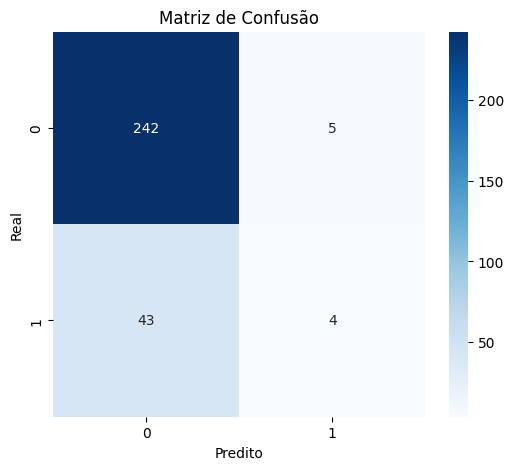

In [11]:
# MATRIZ DE CONFUSÃO

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

Meu modelo está com um comportamento MUITO comum em datasets desbalanceados.

Oque aconteceu em tese? este dataset tem muito mais No Attrition do que Yes Attrition,o modelo aprendeu a prever quase tudo como 0
por isso:

Accuracy ficou alta (83%)
mas Recall ficou péssimo (8%)

Na prática:

ele quase não detecta quem vai sair da empresa.  
Sua matriz mostra isso claramente:

Real	Predito	Quantidade  
0 → 0	Verdadeiro Negativo	242  
0 → 1	Falso Positivo	5  
1 → 0	Falso Negativo	43  
1 → 1	Verdadeiro Positivo	4  

# aplicar o smote no dataset

Serve para gerar exemplos sintéticos da classe minoritária. Isso equilibra as classes e ajuda o modelo a aprender padrões da classe “Yes” sem simplesmente duplicar registros.

In [14]:
from imblearn.over_sampling import SMOTE

# SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Antes:", y_train.value_counts())

print("Depois:", y_train_smote.value_counts())

Antes: Attrition
0    986
1    190
Name: count, dtype: int64
Depois: Attrition
0    986
1    986
Name: count, dtype: int64


In [15]:
# MODELO

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

# TREINAMENTO

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Modelo treinado.")

Modelo treinado.


In [16]:
# previsões

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [17]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8435374149659864
Precision: 0.5172413793103449
Recall   : 0.3191489361702128
F1-Score : 0.39473684210526316
ROC-AUC  : 0.7418382289602895


O dataset era desbalanceado, então o modelo inicialmente apresentava alta accuracy, mas recall muito baixo, identificando poucos funcionários com risco de saída.

Para resolver isso, apliquei SMOTE para balanceamento das classes.

Após o balanceamento, o recall aumentou significativamente, melhorando a capacidade do modelo em detectar colaboradores com maior probabilidade de attrition.

In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
11,StockOptionLevel,0.085265
6,MonthlyIncome,0.078808
5,JobSatisfaction,0.058687
12,TotalWorkingYears,0.054523
0,Age,0.054521
35,MaritalStatus_Married,0.051493
3,EnvironmentSatisfaction,0.051372
15,YearsAtCompany,0.048077
1,DistanceFromHome,0.040129
14,WorkLifeBalance,0.037640


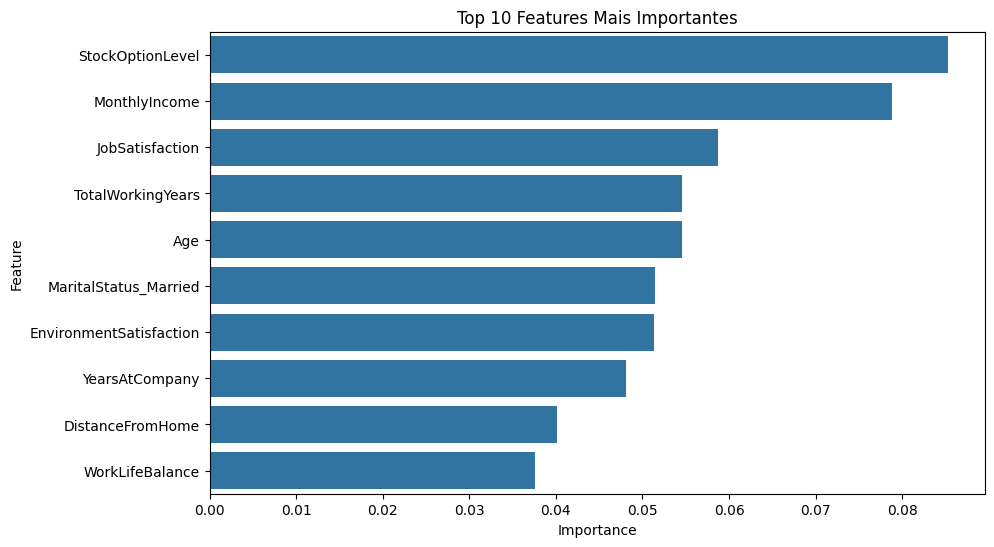

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Mais Importantes")

plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

# RANDOM FOREST BALANCEADO

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

# treino
rf_balanced.fit(
    X_train,
    y_train
)

print("Modelo treinado.")

Modelo treinado.


In [22]:
# previsões

y_pred_bal = rf_balanced.predict(X_test)
y_prob_bal = rf_balanced.predict_proba(X_test)[:, 1]

In [23]:
# Avaliação
print("Accuracy :", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall   :", recall_score(y_test, y_pred_bal))
print("F1-Score :", f1_score(y_test, y_pred_bal))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_bal))

Accuracy : 0.8435374149659864
Precision: 0.5714285714285714
Recall   : 0.0851063829787234
F1-Score : 0.14814814814814814
ROC-AUC  : 0.7907657851666811


In [25]:
y_pred_threshold = (y_prob_bal >= 0.3).astype(int)

# comparação dos modelos

comparacao = pd.DataFrame({
    "Modelo": [
        "Random Forest Original",
        "Random Forest + SMOTE",
        "RF + class_weight",
        "RF + Threshold 0.3"
    ],

    "Accuracy": [
        0.8367,
        0.8435,
        accuracy_score(y_test, y_pred_bal),
        accuracy_score(y_test, y_pred_threshold)
    ],

    "Precision": [
        0.4444,
        0.5172,
        precision_score(y_test, y_pred_bal),
        precision_score(y_test, y_pred_threshold)
    ],

    "Recall": [
        0.0851,
        0.3191,
        recall_score(y_test, y_pred_bal),
        recall_score(y_test, y_pred_threshold)
    ],

    "F1-Score": [
        0.1428,
        0.3947,
        f1_score(y_test, y_pred_bal),
        f1_score(y_test, y_pred_threshold)
    ],

    "ROC-AUC": [
        0.8151,
        0.7418,
        roc_auc_score(y_test, y_prob_bal),
        roc_auc_score(y_test, y_prob_bal)
    ]
})

comparacao

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest Original,0.836700,0.444400,0.085100,0.142800,0.815100
1,Random Forest + SMOTE,0.843500,0.517200,0.319100,0.394700,0.741800
2,RF + class_weight,0.843537,0.571429,0.085106,0.148148,0.790766
3,RF + Threshold 0.3,0.836735,0.487179,0.404255,0.441860,0.790766


In [40]:
# novo threshold

threshold = 0.3

y_pred_threshold = (
    y_prob_bal >= threshold
).astype(int)

In [41]:
# avaliação com novo threshold
print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
print("Precision:", precision_score(y_test, y_pred_threshold))
print("Recall   :", recall_score(y_test, y_pred_threshold))
print("F1-Score :", f1_score(y_test, y_pred_threshold))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_bal))

Accuracy : 0.8367346938775511
Precision: 0.48717948717948717
Recall   : 0.40425531914893614
F1-Score : 0.4418604651162791
ROC-AUC  : 0.7907657851666811


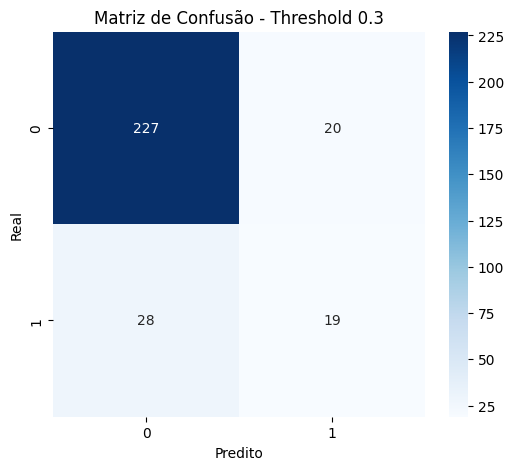

In [42]:
cm = confusion_matrix(
    y_test,
    y_pred_threshold
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Matriz de Confusão - Threshold {threshold}"
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [44]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Separar features e target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicar SMOTE no treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Treinar modelo com class_weight="balanced"
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_res, y_train_res)

# Avaliar
y_pred = model.predict(X_test)
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

Matriz de Confusão:
 [[326  44]
 [ 39  32]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89       370
           1       0.42      0.45      0.44        71

    accuracy                           0.81       441
   macro avg       0.66      0.67      0.66       441
weighted avg       0.82      0.81      0.81       441



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
from xgboost import XGBClassifier


In [47]:
# MODELO XGBOOST

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# treino
xgb_model.fit(
    X_train_res,
    y_train_res
)

print("XGBoost treinado.")

XGBoost treinado.


Eu configurei e treinei um **modelo XGBoost** para prever a saída de funcionários.  

 **Escolhi o algoritmo XGBoost** porque ele é poderoso para lidar com dados complexos e desbalanceados.  
- **Defini os parâmetros principais**:
  - `n_estimators=300`: pedi para o modelo construir 300 árvores, aumentando a capacidade de aprender padrões.  
  - `max_depth=5`: limitei a profundidade das árvores para evitar overfitting.  
  - `learning_rate=0.05`: defini uma taxa de aprendizado baixa, para que o modelo aprenda de forma mais gradual e estável.  
  - `subsample=0.8`: usei 80% dos dados em cada árvore, introduzindo aleatoriedade e robustez.  
  - `colsample_bytree=0.8`: usei 80% das variáveis em cada árvore, para aumentar a diversidade.  
  - `random_state=42`: garanti reprodutibilidade.  
  - `eval_metric="logloss"`: escolhi logloss como métrica de avaliação durante o treino, adequada para classificação binária.  

- **Treinei o modelo (`fit`)** usando os dados balanceados pelo SMOTE (`X_train_res`, `y_train_res`).  
- Com isso, o modelo aprendeu em um cenário mais equilibrado entre “Yes” e “No Attrition”, o que deve melhorar o recall da classe minoritária.  

In [48]:
# previsões

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [49]:
# avaliação com xgb

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.8367346938775511
Precision: 0.4897959183673469
Recall   : 0.3380281690140845
F1-Score : 0.4
ROC-AUC  : 0.7439665017129806


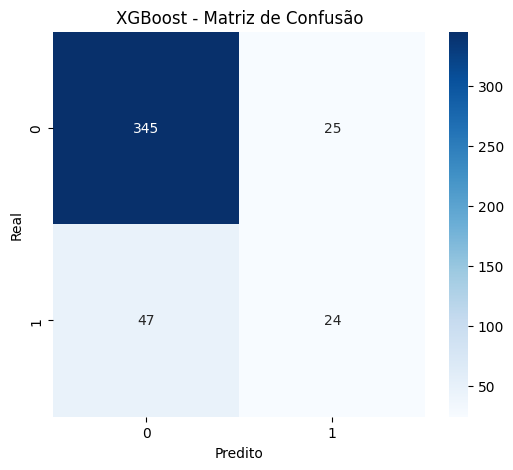

In [50]:
cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost - Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

In [58]:
# =========================================
# NOVO THRESHOLD
# =========================================

threshold = 0.3

y_pred_xgb_threshold = (
    y_prob_xgb >= threshold
).astype(int)

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb_threshold))

print("Precision:", precision_score(y_test, y_pred_xgb_threshold))

print("Recall   :", recall_score(y_test, y_pred_xgb_threshold))

print("F1-Score :", f1_score(y_test, y_pred_xgb_threshold))

Accuracy : 0.8140589569160998
Precision: 0.417910447761194
Recall   : 0.39436619718309857
F1-Score : 0.4057971014492754


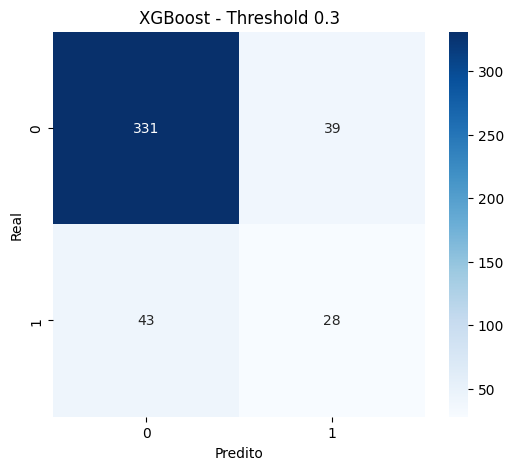

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_xgb_threshold
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"XGBoost - Threshold {threshold}"
)

plt.xlabel("Predito")

plt.ylabel("Real")

plt.show()

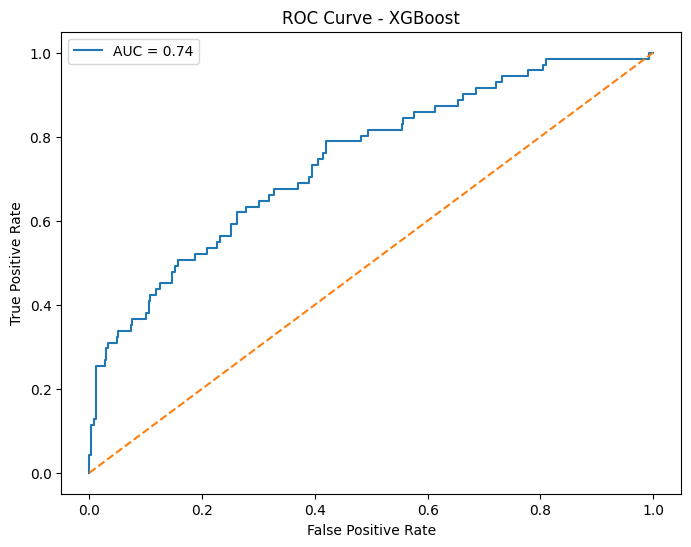

In [61]:
from sklearn.metrics import roc_curve, auc

# =========================================
# ROC CURVE
# =========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_xgb
)

roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

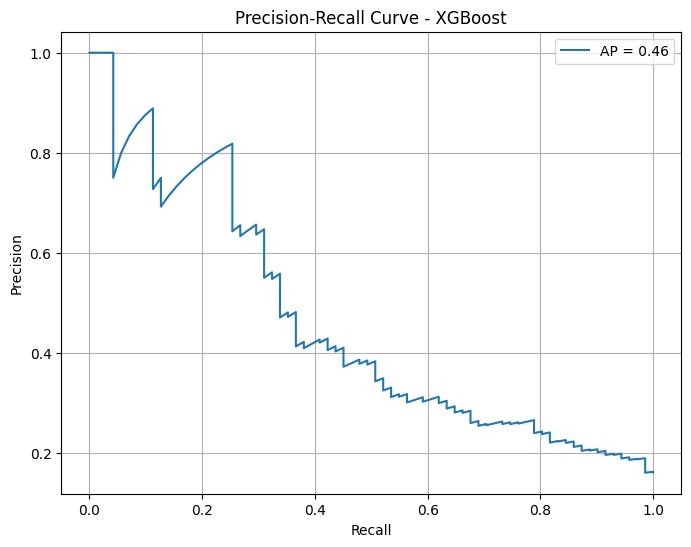

In [62]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# =========================================
# PRECISION RECALL CURVE
# =========================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)

ap_score = average_precision_score(
    y_test,
    y_prob_xgb
)

# plot
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap_score:.2f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - XGBoost")

plt.legend()

plt.grid(True)

plt.show()

In [63]:
# CALCULAR F1 PARA CADA THRESHOLD

f1_scores = (
    2 * (precision * recall)
) / (precision + recall + 1e-10)

# melhor índice
best_idx = np.argmax(f1_scores)

# melhor threshold
best_threshold = thresholds[best_idx]

print("Melhor Threshold:", best_threshold)

print("Melhor F1:", f1_scores[best_idx])

print("Precision:", precision[best_idx])

print("Recall:", recall[best_idx])

Melhor Threshold: 0.19585828
Melhor F1: 0.4363636363146079
Precision: 0.3829787234042553
Recall: 0.5070422535211268


In [64]:
# =========================================
# NOVAS PREVISÕES
# =========================================

y_pred_best = (
    y_prob_xgb >= best_threshold
).astype(int)

In [65]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))

print("Precision:", precision_score(y_test, y_pred_best))

print("Recall   :", recall_score(y_test, y_pred_best))

print("F1-Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.7891156462585034
Precision: 0.3829787234042553
Recall   : 0.5070422535211268
F1-Score : 0.43636363636363634


Em resumo:
fui implementar um método objetivo para encontrar o threshold que maximiza o F1-score, e com isso consegui aumentar recall para mais de 50%, tornando o modelo muito mais aplicável na prática.

Os próximo passo, exploarar a importância das variáveis.

scale_pos_weight no XGBoost  
hyperparameter tuning  
feature engineering  
ensembles.    


```
# Isto está formatado como código
```



scale_pos_weight no XGBoost é um hiperparâmetro usado para lidar com conjuntos de dados de classificação binária desbalanceados (quando você tem muito mais exemplos de uma classe do que de outra)

# Como funciona?

Ele atribui um peso maior aos erros cometidos na classe positiva (geralmente a classe minoritária, como "fraude" ou "doença"). Isso força o modelo a prestar mais atenção nela, em vez de focar apenas na classe majoritária para obter uma acurácia alta, mas inútil.

# O que acontece na prática?

Aumenta o Recall: O modelo fica melhor em encontrar os casos positivos.Diminui a Precisão: Pode haver um aumento de "falsos positivos".Probabilidades: As probabilidades previstas podem ficar descalibradas (não refletindo a probabilidade real, mas sim a importância ajustada)

In [67]:
# scaçe pos weight

scale_pos_weight = (
    y_train.value_counts()[0]
    /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

5.198795180722891


In [68]:
# XGBOOST BALANCEADO

xgb_balanced = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    eval_metric="logloss"
)

# treino
xgb_balanced.fit(
    X_train,
    y_train
)

print("Modelo treinado.")

Modelo treinado.


In [69]:
# previsões

y_pred_bal = xgb_balanced.predict(X_test)
y_prob_bal = xgb_balanced.predict_proba(X_test)[:, 1]

In [70]:
# metricas

print("Accuracy :", accuracy_score(y_test, y_pred_bal))
print("Precision:", precision_score(y_test, y_pred_bal))
print("Recall   :", recall_score(y_test, y_pred_bal))
print("F1-Score :", f1_score(y_test, y_pred_bal))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_bal))

Accuracy : 0.8321995464852607
Precision: 0.46808510638297873
Recall   : 0.30985915492957744
F1-Score : 0.3728813559322034
ROC-AUC  : 0.7628092881614008


In [71]:
from sklearn.model_selection import RandomizedSearchCV

In [72]:
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [73]:
random_search = RandomizedSearchCV(
    estimator=xgb_balanced,

    param_distributions=param_grid,

    n_iter=20,

    scoring="f1",

    cv=3,

    verbose=1,

    random_state=42,

    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=300, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [74]:
print(random_search.best_params_)

best_model = random_search.best_estimator_

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [75]:
df["IncomePerYear"] = (
    df["MonthlyIncome"] * 12
)

In [76]:
df["IncomeExperienceRatio"] = (
    df["MonthlyIncome"]
    /
    (df["TotalWorkingYears"] + 1)
)

In [77]:
df["PromotionDelay"] = (
    df["YearsAtCompany"]
    -
    df["YearsSinceLastPromotion"]
)

In [78]:
df["OverallSatisfaction"] = (
    df["JobSatisfaction"]
    +
    df["EnvironmentSatisfaction"]
    +
    df["RelationshipSatisfaction"]
    +
    df["WorkLifeBalance"]
) / 4

In [79]:
#  Ensembles
''' Voting Classifier

Combina:

Logistic Regression
Random Forest
XGBoost.'''

from sklearn.ensemble import VotingClassifier

In [86]:
from sklearn.ensemble import VotingClassifier

# =========================================
# ENSEMBLE
# =========================================

ensemble = VotingClassifier(
    estimators=[
        ("lr", model),
        ("rf", rf_model),
        ("xgb", xgb_balanced)
    ],

    voting="soft"
)

In [87]:
ensemble.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(max_depth=12,
                                                     n_estimators=300,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_ca...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [88]:
y_pred_ensemble = ensemble.predict(X_test)
y_prob_ensemble = ensemble.predict_proba(X_test)[:, 1]

In [89]:
# metricas

print("Accuracy :", accuracy_score(y_test, y_pred_ensemble))
print("Precision:", precision_score(y_test, y_pred_ensemble))
print("Recall   :", recall_score(y_test, y_pred_ensemble))
print("F1-Score :", f1_score(y_test, y_pred_ensemble))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_ensemble))

Accuracy : 0.8616780045351474
Precision: 0.6136363636363636
Recall   : 0.38028169014084506
F1-Score : 0.46956521739130436
ROC-AUC  : 0.804339550818424


O ensemble:

ficou mais preciso  
reduziu falsos positivos   
melhorou separação das classes  
aumentou F1-score   
aumentou ROC-AUC.  

# Qual modelo escolher?
Se o objetivo for:  
detectar o máximo possível de saídas   

→ XGBoost com threshold tuning.

# Se o objetivo for:
equilíbrio geral e menos alarmes falsos

→ Ensemble.

Porque:

melhor F1 e ROC-AUC

In [90]:
import pickle

In [91]:
with open("xgboost_attrition_model.pkl", "wb") as file:
    pickle.dump(xgb_balanced, file)

print("XGBoost salvo com sucesso.")

XGBoost salvo com sucesso.


In [92]:
with open("ensemble_attrition_model.pkl", "wb") as file:
    pickle.dump(ensemble, file)

print("Ensemble salvo com sucesso.")

Ensemble salvo com sucesso.


In [93]:
model_columns = X.columns.tolist()

with open("model_columns.pkl", "wb") as file:
    pickle.dump(model_columns, file)

print("Colunas salvas.")

Colunas salvas.


In [ ]:
with open("model_columns.pkl", "rb") as file:
    model_columns = pickle.load(file)